# CivicGuard Dataset Cleaning and Preprocessing

This notebook performs data cleaning and preprocessing on the Jigsaw Toxic Comment dataset. The cleaned dataset is prepared for use in the CivicGuard toxic comment detection system.

Importing library (pandas as pd).
Loading data from train.csv file.

In [7]:
import pandas as pd

In [8]:
df = pd.read_csv('train.csv', encoding='utf-8')
print(df.shape)  # should now show (159571, 8)

(159571, 8)


## **1. Understanding the data**

## Dataset Features

The dataset contains comment text along with six toxicity labels used for multi-label classification.



In [9]:
df.columns.tolist()


['id',
 'comment_text',
 'toxic',
 'severe_toxic',
 'obscene',
 'threat',
 'insult',
 'identity_hate']

## Dataset Preview

The first 10 rows provide an overview of the dataset structure and contents.

In [10]:
df.head(10)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0
5,00025465d4725e87,"""\n\nCongratulations from me as well, use the ...",0,0,0,0,0,0
6,0002bcb3da6cb337,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,1,1,1,0,1,0
7,00031b1e95af7921,Your vandalism to the Matt Shirvington article...,0,0,0,0,0,0
8,00037261f536c51d,Sorry if the word 'nonsense' was offensive to ...,0,0,0,0,0,0
9,00040093b2687caa,alignment on this subject and which are contra...,0,0,0,0,0,0


## Final Records Preview

The last 10 rows help verify dataset completeness and consistency.

In [11]:
df.tail(10)

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
159561,ffd2e85b07b3c7e4,"""\nNo he did not, read it again (I would have ...",0,0,0,0,0,0
159562,ffd72e9766c09c97,"""\n Auto guides and the motoring press are not...",0,0,0,0,0,0
159563,ffe029a7c79dc7fe,"""\nplease identify what part of BLP applies be...",0,0,0,0,0,0
159564,ffe897e7f7182c90,Catalan independentism is the social movement ...,0,0,0,0,0,0
159565,ffe8b9316245be30,The numbers in parentheses are the additional ...,0,0,0,0,0,0
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0,0,0,0
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0,0,0,0
159570,fff46fc426af1f9a,"""\nAnd ... I really don't think you understand...",0,0,0,0,0,0


## Label Distribution

This analysis shows the frequency of each toxicity category in the dataset.

In [12]:
labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

for label in labels:
    count = df[label].sum()
    percentage = (count / len(df)) * 100
    print(f"{label}: {count} comments ({percentage:.2f}%)")

toxic: 15294 comments (9.58%)
severe_toxic: 1595 comments (1.00%)
obscene: 8449 comments (5.29%)
threat: 478 comments (0.30%)
insult: 7877 comments (4.94%)
identity_hate: 1405 comments (0.88%)


## Toxic Comment Examples

The following examples demonstrate comments labelled as toxic.

In [13]:
toxic_comments = df[df['toxic'] == 1]['comment_text']
print(toxic_comments.iloc[0])
print("---")
print(toxic_comments.iloc[1])
print("---")
print(toxic_comments.iloc[2])

COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK
---
Hey... what is it..
@ | talk .
What is it... an exclusive group of some WP TALIBANS...who are good at destroying, self-appointed purist who GANG UP any one who asks them questions abt their ANTI-SOCIAL and DESTRUCTIVE (non)-contribution at WP?

Ask Sityush to clean up his behavior than issue me nonsensical warnings...
---
Bye! 

Don't look, come or think of comming back! Tosser.


## Non-Toxic Comment Examples

The following examples demonstrate comments that are not labelled as toxic.

In [14]:
clean_comments = df[df['toxic'] == 0]['comment_text']
print(clean_comments.iloc[0])
print("---")
print(clean_comments.iloc[1])

Explanation
Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27
---
D'aww! He matches this background colour I'm seemingly stuck with. Thanks.  (talk) 21:51, January 11, 2016 (UTC)



## Most Toxic Comment

This comment received the highest number of toxicity labels simultaneously.

In [15]:
df['label_count'] = df[labels].sum(axis=1)
most_toxic = df[df['label_count'] == df['label_count'].max()]
print(most_toxic[['comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']].iloc[0])

comment_text     WOULDN'T BE THE FIRST TIME BITCH. FUCK YOU I'L...
toxic                                                            1
severe_toxic                                                     1
obscene                                                          1
threat                                                           1
insult                                                           1
identity_hate                                                    1
Name: 1017, dtype: object


# 2. **Cleaning the data **

CivicGuard uses DistilBERT, which was pre-trained on raw, natural text — so it actually needs casing, punctuation, and emoji context to work properly.
What we keep and why:

Casing — "KILL" signals more intensity than "kill"
Punctuation — DistilBERT's vocabulary includes ! ? .
Emojis — converted to text (💀 → skull) to preserve threat context

What we remove:

URLs — carry no toxicity signal
Repeated characters — haaaate → haate (reduce noise, keep emphasis)
Extra whitespace — basic hygiene


Rule of thumb: give BERT text that looks like natural human writing.


## Missing Value Inspection

Before cleaning, the dataset is checked for missing or empty values.

In [16]:
# Check nulls before cleaning
print("=== NULL VALUES BEFORE CLEANING ===")
print(df.isnull().sum())
print(f"\nTotal rows before: {len(df)}")

=== NULL VALUES BEFORE CLEANING ===
id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
label_count      0
dtype: int64

Total rows before: 159571


 ## Library Installation
 Install libraries: !pip install emoji


In [17]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 15.6 MB/s eta 0:00:00


## Text Cleaning Function

The following function removes noise while preserving useful contextual information.


In [18]:
import re
import emoji

def clean_text(text):
    if not isinstance(text, str):
        return ""
    # 1. Remove URLs (including Wikipedia [http format)
    text = re.sub(r'\[?https?://\S+|www\.\S+', "", text)
    # 2. Convert emojis to text
    text = emoji.demojize(text, delimiters=(" ", " "))
    # 3. Normalize repeated characters
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    # 4. Collapse whitespace
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['clean_text'] = df['comment_text'].apply(clean_text)
df = df[df['clean_text'].str.strip() != '']
df.to_csv("cleaned_train.csv", index=False)
print("Saved!")

Saved!


## Apply Cleaning

The cleaning function is applied to all comments in the dataset.


In [19]:
df["clean_text"] = df["comment_text"].apply(clean_text)
print(df[["comment_text", "clean_text"]].head())

                                        comment_text  \
0  Explanation\nWhy the edits made under my usern...   
1  D'aww! He matches this background colour I'm s...   
2  Hey man, I'm really not trying to edit war. It...   
3  "\nMore\nI can't make any real suggestions on ...   
4  You, sir, are my hero. Any chance you remember...   

                                          clean_text  
0  Explanation Why the edits made under my userna...  
1  D'aww! He matches this background colour I'm s...  
2  Hey man, I'm really not trying to edit war. It...  
3  " More I can't make any real suggestions on im...  
4  You, sir, are my hero. Any chance you remember...  


## Save Cleaned Dataset

The cleaned dataset is stored for later model training.

In [20]:
df.to_csv("cleaned_train.csv", index=False)
print("Done!")

Done!


## **3. Visualization of the data**

## Library Installation
Installed visualization libraries:

In [21]:
!pip install matplotlib seaborn wordcloud

## Toxicity Distribution

This visualization shows the number of comments associated with each toxicity label.

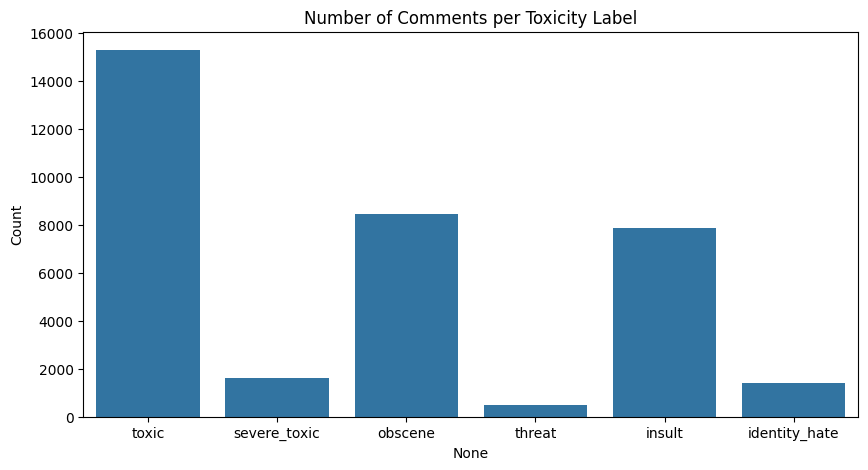

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

counts = df[labels].sum()
plt.figure(figsize=(10, 5))
sns.barplot(x=counts.index, y=counts.values)
plt.title("Number of Comments per Toxicity Label")
plt.ylabel("Count")
plt.show()

## Comment Length Distribution

This histogram illustrates the variation in comment lengths across the dataset.

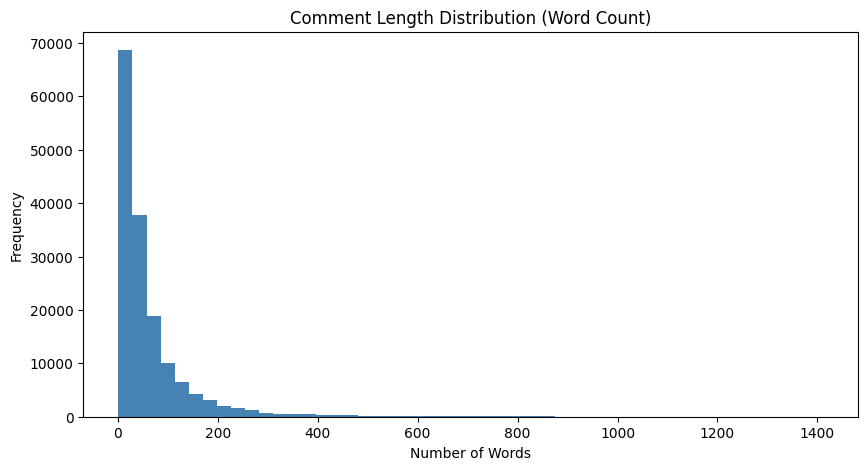

In [23]:
df["text_length"] = df["clean_text"].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 5))
plt.hist(df["text_length"], bins=50, color="steelblue")
plt.title("Comment Length Distribution (Word Count)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

## Toxic Comment Word Cloud

The word cloud highlights frequently occurring words within toxic comments.

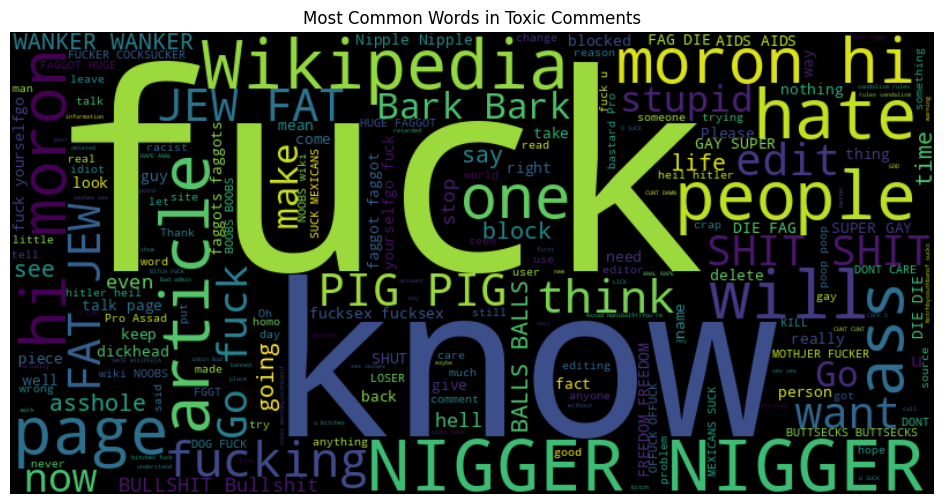

In [24]:
from wordcloud import WordCloud

toxic_text = " ".join(df[df["toxic"] == 1]["clean_text"])

wordcloud = WordCloud(width=800, height=400, background_color="black").generate(toxic_text)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Toxic Comments")
plt.show()